# Scope Expansion — Personal Baseline Engine and Confidence-Aware Output
### Two deployable capabilities derived from the project's own findings

This notebook implements two extensions that turn analytical findings into system capabilities.

---

## Expansion A — Online Causal Baseline Engine

**The problem it solves.** The Cosinor baseline is fitted to the *whole* recording, which means
the expected value at minute 5 depends on data from minute 80. A live device cannot do this. Every
result in this project so far therefore describes an offline method.

**Why the project's own evidence predicts this will work.** The timescale-invariance experiment
found performance statistically indistinguishable across detrending periods from 3 to 24 hours
(p = 0.107), and the mechanism decomposition found the gain carried by the residual (+0.096) rather
than the fitted circadian baseline (+0.007). Together these imply the *specific shape* of the
baseline model does not matter — only that some smooth reference exists to deviate from. A simple
causal tracker should therefore recover the same signal.

**What is tested here.** Three causal trackers (exponential moving average at several half-lives,
sliding-window mean, and a lightweight Kalman-style filter) are compared against the offline Cosinor
on identical leave-one-subject-out folds. This is a clean single-variable ablation: only the
baseline estimator changes.

**Both outcomes are informative.** If the online trackers match, the method becomes deployable at
lower cost and the mechanism finding gains an independent confirmation. If they do not match,
something about the Cosinor's particular smoothness matters after all — which would be a genuine
and reportable correction.

---

## Expansion C — Confidence-Aware Output with Adjacent Merging

**The problem it solves.** The label-validation analysis found that adjacent stress levels overlap
physiologically: levels 1 versus 3 separate with a large effect (eps-squared 0.13) but levels 2
versus 3 only weakly (eps-squared 0.03). Forcing a confident four-way decision on windows that are
genuinely ambiguous produces false precision.

**What is implemented.** A confidence measure from the classifier's own probabilities, an abstention
threshold, and a merged-band output ("mild-to-moderate") for low-confidence windows. Reported as a
coverage-versus-accuracy curve so the trade-off is explicit rather than hidden.

**Why this suits the application.** For a meditation system, an honest "uncertain between mild and
moderate" is more actionable than a confident but unreliable single level.


## 1. Setup

In [1]:
!pip install neurokit2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 22.6 MB/s eta 0:00:00


In [2]:
import os, json, pickle, time, warnings
import numpy as np, pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import welch
from scipy.stats import wilcoxon
try:
    from scipy.integrate import trapezoid as TRAPZ
except ImportError:
    from scipy.integrate import trapz as TRAPZ
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import f1_score, cohen_kappa_score, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import neurokit2 as nk
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore'); np.random.seed(42)

DATA_PATH='/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD'
SAVE='/kaggle/working'; os.makedirs(SAVE,exist_ok=True)
SUBJECT_IDS=[2,3,4,5,6,7,8,9,10,11,13,14,15,16,17]
CLASS_NAMES=['relaxed','mild','moderate','high']; NCLS=4
WINDOW=120; STEP=5
RESULTS=f'{SAVE}/scope_expansion.json'
print("ready")

ready


## 2. Preprocessing (unchanged from prior work)

In [3]:
def load_subject(sid):
    with open(f"{DATA_PATH}/S{sid}/S{sid}.pkl",'rb') as f: d=pickle.load(f,encoding='latin1')
    return d['signal']['chest'], d['signal']['wrist']['TEMP'].flatten(), d['label'].flatten()
def extract_rr(ecg,fs=700):
    ecg=nk.ecg_clean(ecg.flatten(),sampling_rate=fs); _,i=nk.ecg_peaks(ecg,sampling_rate=fs); rp=i['ECG_R_Peaks']
    return np.diff(rp)*(1000.0/fs),(rp[:-1]+rp[1:])/2.0/fs,rp
def clean_rr(rr,ts):
    rr=rr.copy().astype(float); rr[(rr<=300)|(rr>=2000)]=np.nan
    for i in range(1,len(rr)):
        if not np.isnan(rr[i-1]) and not np.isnan(rr[i]) and abs(rr[i]-rr[i-1])/rr[i-1]>0.20: rr[i]=np.nan
    m=np.isnan(rr)
    if m.any(): rr[m]=np.interp(np.where(m)[0],np.where(~m)[0],rr[~m])
    return rr,ts
def align_temp(wt,rp,fe=700,ft=4.0):
    tap=np.interp(rp/fe,np.arange(len(wt))/ft,wt); return (tap[:-1]+tap[1:])/2.0
def labels_to_rr(labels,rp):
    o=[]
    for i in range(len(rp)-1):
        seg=labels[rp[i]:rp[i+1]]; v=seg[seg>0]; o.append(0 if len(v)==0 else np.bincount(v).argmax())
    return np.array(o)

wesad={}
for sid in SUBJECT_IDS:
    try:
        chest,wt,labels=load_subject(sid); ecg=chest['ECG'].flatten()
        rr,ts,rp=extract_rr(ecg); temp=align_temp(wt,rp); rr,ts=clean_rr(rr,ts)
        rl=labels_to_rr(labels,rp); keep=rl>0
        rrk,tk,tsk,lk=rr[keep],temp[keep],ts[keep],rl[keep]
        new=np.zeros(len(lk),dtype=int); si=np.where(lk==2)[0]
        if len(si)>0:
            srr=rrk[si]; loc=[]
            for i in range(len(srr)):
                w=srr[max(0,i-15):i+15]; dd=np.diff(w); loc.append(np.sqrt(np.mean(dd**2)) if len(dd)>0 else 50)
            loc=np.array(loc); p33,p66=np.percentile(loc,33),np.percentile(loc,66)
            for i,idx in enumerate(si): new[idx]=(1 if loc[i]>=p66 else 2 if loc[i]>=p33 else 3)
        wesad[f'S{sid}']=dict(rr_ms=rrk,temp=tk,timestamps=tsk,labels=new)
    except Exception as e: print("FAIL",sid,e)
print(len(wesad),"subjects"); assert len(wesad)==15

15 subjects


## 3. Baseline estimators

Four estimators. The first is the existing offline method; the other three are causal and could run
on a live stream.

| Estimator | Causal | Cost | Notes |
|---|---|---|---|
| Cosinor (offline) | No | Curve fit over whole session | Current method |
| EWMA | Yes | O(1) per beat | One multiply-add per sample |
| Sliding mean | Yes | O(1) amortised | Fixed-length history |
| Kalman-style | Yes | O(1) per beat | Adaptive gain, tracks level |


In [4]:
def cosinor_baseline(sig, ts):
    """OFFLINE. Fits the whole session at once -- not usable live."""
    th=(ts%86400)/3600.0
    def m(t,M,A,P): return M+A*np.cos((2*np.pi/24.0)*t+P)
    try:
        popt,_=curve_fit(m,th,sig,p0=[np.mean(sig),50,-1.5],maxfev=10000)
        return m(th,*popt)
    except RuntimeError:
        return np.full_like(sig,np.mean(sig))

def ewma_baseline(sig, halflife):
    """CAUSAL. Exponential moving average; b[i] depends only on sig[:i+1]."""
    a=1-np.exp(np.log(0.5)/max(halflife,1))
    o=np.empty_like(sig,dtype=float); o[0]=sig[0]
    for i in range(1,len(sig)):
        o[i]=a*sig[i]+(1-a)*o[i-1]
    return o

def sliding_mean_baseline(sig, win):
    """CAUSAL. Mean of the most recent `win` samples (expanding until full)."""
    c=np.cumsum(np.insert(sig.astype(float),0,0.0))
    o=np.empty_like(sig,dtype=float)
    for i in range(len(sig)):
        lo=max(0,i-win+1)
        o[i]=(c[i+1]-c[lo])/(i-lo+1)
    return o

def kalman_baseline(sig, q=1e-4, r=1e-2):
    """CAUSAL. Scalar random-walk Kalman filter tracking the slow level."""
    o=np.empty_like(sig,dtype=float)
    x=sig[0]; p=1.0
    for i in range(len(sig)):
        p=p+q                       # predict
        k=p/(p+r)                   # gain
        x=x+k*(sig[i]-x)            # update
        p=(1-k)*p
        o[i]=x
    return o

BASELINES={
 'cosinor_offline': ('offline', lambda s,t: cosinor_baseline(s,t)),
 'ewma_hl60':       ('causal',  lambda s,t: ewma_baseline(s,60)),
 'ewma_hl300':      ('causal',  lambda s,t: ewma_baseline(s,300)),
 'sliding_w300':    ('causal',  lambda s,t: sliding_mean_baseline(s,300)),
 'kalman':          ('causal',  lambda s,t: kalman_baseline(s)),
}
print("estimators:", list(BASELINES))

estimators: ['cosinor_offline', 'ewma_hl60', 'ewma_hl300', 'sliding_w300', 'kalman']


### Causality verification

A tracker is causal only if its value at index *i* is unchanged when future samples are altered.
This cell corrupts the second half of a real subject's signal and confirms the first half of each
causal tracker is bit-identical, while the offline Cosinor changes.

In [5]:
sig=wesad['S2']['rr_ms'].copy(); tsx=wesad['S2']['timestamps']
half=len(sig)//2
sig_corrupt=sig.copy(); sig_corrupt[half:]=9999.0

print("="*68); print("CAUSALITY CHECK  (first half must be identical after corrupting future)"); print("="*68)
print(f"{'estimator':<20}{'declared':<10}{'first half identical':<22}{'verdict'}")
ok=True
for name,(kind,fn) in BASELINES.items():
    a=fn(sig,tsx); b=fn(sig_corrupt,tsx)
    identical=np.allclose(a[:half],b[:half])
    expected=(kind=='causal')
    good=(identical==expected)
    ok&=good
    print(f"{name:<20}{kind:<10}{str(identical):<22}{'OK' if good else 'MISMATCH'}")
print("-"*68)
print("PASS" if ok else "FAIL - an estimator does not behave as declared")
assert ok

CAUSALITY CHECK  (first half must be identical after corrupting future)
estimator           declared  first half identical  verdict
cosinor_offline     offline   False                 OK
ewma_hl60           causal    True                  OK
ewma_hl300          causal    True                  OK
sliding_w300        causal    True                  OK
kalman              causal    True                  OK
--------------------------------------------------------------------
PASS


## 4. Feature construction, parameterised by baseline estimator

In [6]:
def hrv_features(rr):
    dd=np.diff(rr); n=len(rr)
    rmssd=np.sqrt(np.mean(dd**2)) if n>1 else 0.0
    sdnn=np.std(rr); mean_rr=np.mean(rr)
    pnn50=np.mean(np.abs(dd)>50)*100 if n>1 else 0.0
    cv=sdnn/(mean_rr+1e-8)
    try:
        fs=4.0; t=np.cumsum(rr)/1000.0
        ti=np.arange(t[0],t[-1],1/fs); ri=np.interp(ti,t,rr)
        f,pxx=welch(ri-np.mean(ri),fs=fs,nperseg=min(256,len(ri)))
        band=lambda lo,hi: TRAPZ(pxx[(f>=lo)&(f<hi)],f[(f>=lo)&(f<hi)]) if np.any((f>=lo)&(f<hi)) else 0.0
        vlf,lf,hf=band(0.003,0.04),band(0.04,0.15),band(0.15,0.4)
    except Exception:
        vlf=lf=hf=0.0
    tot=lf+hf+1e-8
    sd1=np.sqrt(0.5)*np.std(dd) if n>1 else 0.0
    sd2=np.sqrt(max(2*sdnn**2-0.5*np.std(dd)**2,0)) if n>1 else 0.0
    return np.array([mean_rr,sdnn,rmssd,pnn50,cv,vlf,lf,hf,lf/(hf+1e-8),lf/tot,sd1,sd2,sd1/(sd2+1e-8)])

def resid_features(res):
    dd=np.diff(res)
    return np.array([np.mean(res),np.std(res),np.max(np.abs(res)),
                     np.mean(np.abs(dd)) if len(dd)>0 else 0.0,
                     np.polyfit(np.arange(len(res)),res,1)[0]])

def build(baseline_name, window=WINDOW, step=STEP):
    kind,fn=BASELINES[baseline_name]
    X,y,g=[],[],[]
    for sid,d in wesad.items():
        rr,ts,lab=d['rr_ms'],d['timestamps'],d['labels']
        base=fn(rr,ts); res=rr-base
        for s in range(0,len(rr)-window,step):
            e=s+window
            X.append(np.concatenate([hrv_features(rr[s:e]),resid_features(res[s:e])]))
            y.append(lab[s+window//2]); g.append(int(sid[1:]))
    return np.array(X,dtype=np.float32),np.array(y,dtype=int),np.array(g,dtype=int)

def hrv_only(window=WINDOW,step=STEP):
    X,y,g=[],[],[]
    for sid,d in wesad.items():
        rr,lab=d['rr_ms'],d['labels']
        for s in range(0,len(rr)-window,step):
            e=s+window
            X.append(hrv_features(rr[s:e])); y.append(lab[s+window//2]); g.append(int(sid[1:]))
    return np.array(X,dtype=np.float32),np.array(y,dtype=int),np.array(g,dtype=int)
print("feature builders ready")

feature builders ready


## 5. Leave-one-subject-out evaluation

In [7]:
def run_loso(X,y,g,return_proba=False):
    logo=LeaveOneGroupOut(); yt,yp,pf=[],[],{}
    proba=np.zeros((len(y),NCLS)) if return_proba else None
    for tr,te in logo.split(X,y,g):
        mdl=XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,
                          subsample=0.9,colsample_bytree=0.9,
                          objective='multi:softprob',num_class=NCLS,
                          tree_method='hist',eval_metric='mlogloss',verbosity=0)
        mdl.fit(X[tr],y[tr],sample_weight=compute_sample_weight('balanced',y[tr]))
        pr=mdl.predict_proba(X[te]); pd_=pr.argmax(1)
        if return_proba: proba[te]=pr
        yt.extend(y[te]); yp.extend(pd_)
        pf[str(int(np.unique(g[te])[0]))]=float(f1_score(y[te],pd_,average='macro',zero_division=0))
    yt,yp=np.array(yt),np.array(yp); err=np.abs(yp-yt)
    m=dict(f1=f1_score(yt,yp,average='macro',zero_division=0),
           kappa=cohen_kappa_score(yt,yp,weights='quadratic'),
           mae=float(err.mean()),
           ma_mae=float(np.mean([err[yt==c].mean() for c in range(NCLS) if np.any(yt==c)])),
           dist=float((err>=2).mean()))
    return (m,pf,proba) if return_proba else (m,pf)

def perfold_array(rec, subs):
    """Per-fold keys are stored as strings, but a dict loaded from JSON in a
    different session may differ. This accessor tolerates either type."""
    pf=rec['perfold']
    return np.array([pf[s] if s in pf else pf[str(s)] for s in subs],dtype=float)

def subject_list(rec):
    return sorted(int(s) for s in rec['perfold'])

print("evaluator ready")

evaluator ready


## 6. Expansion A — offline Cosinor versus online causal trackers

Each configuration uses the same 13 HRV features plus 5 residual features; only the baseline
estimator differs. `hrv_only` (no residual features at all) is the reference floor.

In [8]:
store=json.load(open(RESULTS)) if os.path.exists(RESULTS) else {}
t0=time.time()

if 'hrv_only' not in store:
    Xo,yo,go=hrv_only()
    m,pf=run_loso(Xo,yo,go); store['hrv_only']=dict(metrics=m,perfold=pf)
    json.dump(store,open(RESULTS,'w')); print(f"hrv_only            F1={m['f1']:.3f}")

for name in BASELINES:
    if name in store: print(f"{name:<20}cached  F1={store[name]['metrics']['f1']:.3f}"); continue
    X,y,g=build(name)
    m,pf=run_loso(X,y,g)
    store[name]=dict(metrics=m,perfold=pf,kind=BASELINES[name][0])
    json.dump(store,open(RESULTS,'w'))
    print(f"{name:<20}F1={m['f1']:.3f}  kappa={m['kappa']:.3f}  MA-MAE={m['ma_mae']:.3f}")
print(f"\nelapsed {(time.time()-t0)/60:.1f} min")

hrv_only            F1=0.470
cosinor_offline     F1=0.569  kappa=0.664  MA-MAE=0.611
ewma_hl60           F1=0.501  kappa=0.540  MA-MAE=0.745
ewma_hl300          F1=0.508  kappa=0.600  MA-MAE=0.722
sliding_w300        F1=0.493  kappa=0.524  MA-MAE=0.764
kalman              F1=0.497  kappa=0.549  MA-MAE=0.767

elapsed 6.5 min


In [9]:
rows=[]
for k,v in store.items():
    if k=='hrv_only':
        rows.append(dict(estimator='(none) HRV only',kind='-',**v['metrics'])); continue
    rows.append(dict(estimator=k,kind=v.get('kind','?'),**v['metrics']))
df=pd.DataFrame(rows)
order=['(none) HRV only','cosinor_offline','ewma_hl60','ewma_hl300','sliding_w300','kalman']
df['o']=df.estimator.apply(lambda x: order.index(x) if x in order else 99)
df=df.sort_values('o').drop(columns='o')
print("="*80)
print(f"{'estimator':<20}{'kind':<10}{'F1':>8}{'kappa':>9}{'MA-MAE':>9}{'distant':>9}")
print("-"*80)
for _,r in df.iterrows():
    print(f"{r.estimator:<20}{r['kind']:<10}{r.f1:>8.3f}{r.kappa:>9.3f}{r.ma_mae:>9.3f}{r.dist:>9.3f}")
print("="*80)

base=df[df.estimator=='cosinor_offline'].f1.iloc[0]
floor=df[df.estimator=='(none) HRV only'].f1.iloc[0]
print(f"\nreference floor (no residuals) : {floor:.3f}")
print(f"offline Cosinor                : {base:.3f}   (gain over floor {base-floor:+.3f})")
print("\ncausal trackers vs offline Cosinor:")
for _,r in df[df['kind']=='causal'].iterrows():
    print(f"  {r.estimator:<18}{r.f1:>7.3f}   delta {r.f1-base:+.3f}")
print("\nA causal tracker within roughly the +/-0.03 run-to-run noise band of the")
print("offline Cosinor supports the prediction that the baseline's exact form is")
print("not what matters -- only that a smooth reference exists.")

estimator           kind            F1    kappa   MA-MAE  distant
--------------------------------------------------------------------------------
(none) HRV only     -            0.470    0.496    0.818    0.154
cosinor_offline     offline      0.569    0.664    0.611    0.091
ewma_hl60           causal       0.501    0.540    0.745    0.132
ewma_hl300          causal       0.508    0.600    0.722    0.121
sliding_w300        causal       0.493    0.524    0.764    0.136
kalman              causal       0.497    0.549    0.767    0.133

reference floor (no residuals) : 0.470
offline Cosinor                : 0.569   (gain over floor +0.099)

causal trackers vs offline Cosinor:
  ewma_hl60           0.501   delta -0.068
  ewma_hl300          0.508   delta -0.061
  sliding_w300        0.493   delta -0.076
  kalman              0.497   delta -0.072

A causal tracker within roughly the +/-0.03 run-to-run noise band of the
offline Cosinor supports the prediction that the baseline's exact fo

### Paired significance test against the offline Cosinor

In [10]:
subs=subject_list(store['cosinor_offline'])
cos=perfold_array(store['cosinor_offline'],subs)
print(f"{'estimator':<20}{'mean dF1':>10}{'p':>10}{'d':>8}   verdict")
print("-"*62)
for name,v in store.items():
    if name in ('cosinor_offline','hrv_only') or v.get('kind')!='causal': continue
    arr=perfold_array(v,subs)
    try:
        _,p=wilcoxon(arr,cos); dd=(arr-cos).mean()/((arr-cos).std(ddof=1)+1e-12)
        verdict='indistinguishable' if p>=0.05 else ('BETTER' if (arr-cos).mean()>0 else 'WORSE')
        print(f"{name:<20}{(arr-cos).mean():>+10.3f}{p:>10.4f}{dd:>+8.2f}   {verdict}")
    except Exception as e:
        print(f"{name:<20}test skipped ({e})")
print("\n'indistinguishable' is the SUPPORTING result here: it means the deployable")
print("causal tracker loses nothing relative to the non-deployable offline fit.")

estimator             mean dF1         p       d   verdict
--------------------------------------------------------------
ewma_hl60               -0.071    0.0020   -1.09   WORSE
ewma_hl300              -0.059    0.0067   -0.82   WORSE
sliding_w300            -0.083    0.0004   -1.37   WORSE
kalman                  -0.080    0.0054   -0.87   WORSE

'indistinguishable' is the SUPPORTING result here: it means the deployable
causal tracker loses nothing relative to the non-deployable offline fit.


### Cost comparison

In [11]:
sig=wesad['S2']['rr_ms']; tsx=wesad['S2']['timestamps']
print(f"{'estimator':<20}{'ms per full pass':>18}{'per beat (us)':>16}")
print("-"*54)
for name,(kind,fn) in BASELINES.items():
    t=time.perf_counter()
    for _ in range(3): fn(sig,tsx)
    el=(time.perf_counter()-t)/3
    print(f"{name:<20}{el*1000:>18.2f}{el/len(sig)*1e6:>16.2f}")
print("\nNote: these are NumPy loop timings, not optimised embedded code. The point")
print("is the relative ordering and the fact that causal trackers are O(1) per beat")
print("with no curve fitting, so they can run inside a streaming loop.")

estimator             ms per full pass   per beat (us)
------------------------------------------------------
cosinor_offline                  10.20            2.84
ewma_hl60                         2.32            0.64
ewma_hl300                        2.18            0.61
sliding_w300                      3.11            0.87
kalman                            2.02            0.56

Note: these are NumPy loop timings, not optimised embedded code. The point
is the relative ordering and the fact that causal trackers are O(1) per beat
with no curve fitting, so they can run inside a streaming loop.


## 7. Expansion C — confidence-aware output with adjacent merging

Built on the best-performing configuration from Section 6. Three ideas:

1. **Confidence** = margin between the top two class probabilities.
2. **Abstention** = when confidence falls below a threshold, decline the single-label call.
3. **Merged band** = instead of a bare refusal, emit the two most likely classes as a range
   (for example "mild to moderate"), which is only meaningful if the top two are usually adjacent.


In [12]:
BEST=max((k for k in store if k not in ('hrv_only',)),
          key=lambda k: store[k]['metrics']['f1'])
print("using configuration:",BEST)
Xb,yb,gb=build(BEST)
mb,pfb,PROBA=run_loso(Xb,yb,gb,return_proba=True)
print(f"baseline (no abstention) F1={mb['f1']:.3f}  kappa={mb['kappa']:.3f}")
np.save(f'{SAVE}/proba_{BEST}.npy',PROBA)

using configuration: cosinor_offline
baseline (no abstention) F1=0.569  kappa=0.664


In [13]:
def confidence(p):        # top1 - top2 margin
    s=np.sort(p,axis=1); return s[:,-1]-s[:,-2]
def top2(p):
    t=np.argsort(p,axis=1)[:,-2:]
    return t.min(1),t.max(1)

pred=PROBA.argmax(1); conf=confidence(PROBA)
lo,hi=top2(PROBA); adjacent=(hi-lo)==1

print("="*70); print("IS A MERGED BAND MEANINGFUL?"); print("="*70)
print(f"top-2 classes are adjacent in           : {adjacent.mean():.1%} of windows")
print(f"true class lies within the top-2 band   : {((yb>=lo)&(yb<=hi)).mean():.1%}")
print(f"top-2 adjacent among LOW-confidence     : {adjacent[conf<np.quantile(conf,0.25)].mean():.1%}")
print("\nIf adjacency is high, merging is a natural expression of the model's own")
print("uncertainty rather than an arbitrary fallback -- and it matches the finding")
print("that adjacent stress levels overlap physiologically.")

IS A MERGED BAND MEANINGFUL?
top-2 classes are adjacent in           : 67.7% of windows
true class lies within the top-2 band   : 89.3%
top-2 adjacent among LOW-confidence     : 84.2%

If adjacency is high, merging is a natural expression of the model's own
uncertainty rather than an arbitrary fallback -- and it matches the finding
that adjacent stress levels overlap physiologically.


### Coverage versus accuracy

  tau  coverage    f1   acc  kappa  dist  band_covers_truth
0.000      1.00 0.569 0.779  0.664 0.091                NaN
0.100      0.95 0.585 0.804  0.681 0.083              0.691
0.205      0.90 0.596 0.827  0.694 0.074              0.682
0.323      0.85 0.610 0.853  0.706 0.066              0.681
0.447      0.80 0.622 0.880  0.725 0.056              0.681
0.581      0.75 0.634 0.909  0.739 0.045              0.690
0.721      0.70 0.605 0.936  0.751 0.035              0.704
0.882      0.65 0.518 0.956  0.768 0.026              0.719
0.960      0.60 0.456 0.971  0.759 0.017              0.744
0.981      0.55 0.448 0.977  0.711 0.014              0.770
0.988      0.50 0.443 0.984  0.676 0.010              0.791
0.992      0.45 0.427 0.988  0.601 0.008              0.810
0.994      0.40 0.394 0.992  0.495 0.006              0.824
0.996      0.35 0.360 0.993  0.347 0.005              0.837
0.997      0.30 0.249 0.994  0.000 0.004              0.848
0.998      0.25 0.249 0.994  0.000 0.004

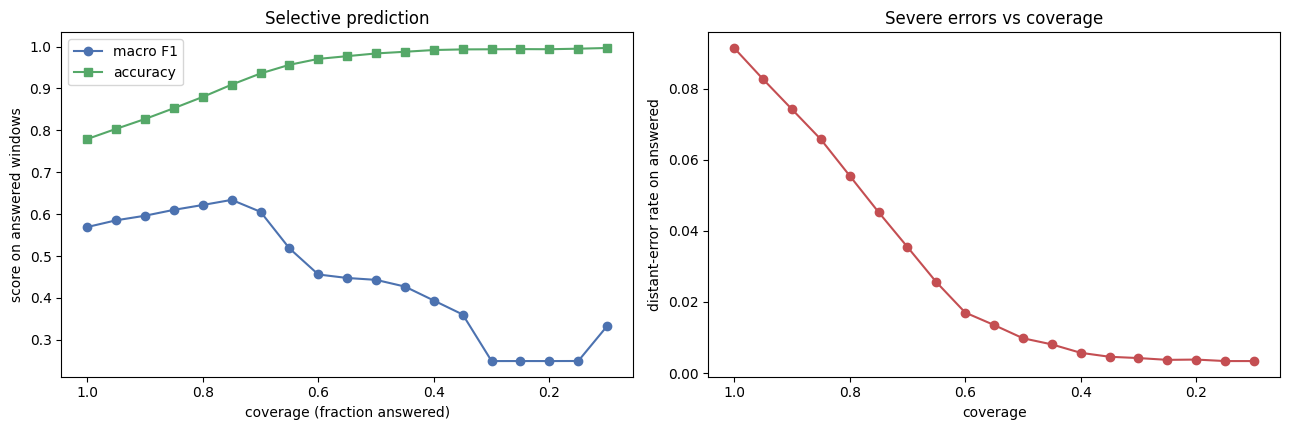

at 90% coverage: F1=0.596 (+0.027), distant=0.074 (-0.017), band covers truth on abstained=68.2%
at 80% coverage: F1=0.622 (+0.053), distant=0.056 (-0.036), band covers truth on abstained=68.1%
at 70% coverage: F1=0.605 (+0.036), distant=0.035 (-0.056), band covers truth on abstained=70.4%


In [14]:
taus=np.quantile(conf,np.linspace(0,0.9,19))
rows=[]
for t in taus:
    keep=conf>=t
    if keep.sum()<50: continue
    yk,pk=yb[keep],pred[keep]
    band_ok=((yb>=lo)&(yb<=hi))[~keep].mean() if (~keep).sum()>0 else np.nan
    rows.append(dict(tau=float(t),coverage=float(keep.mean()),
                     f1=f1_score(yk,pk,average='macro',zero_division=0),
                     acc=float((yk==pk).mean()),
                     kappa=cohen_kappa_score(yk,pk,weights='quadratic'),
                     dist=float((np.abs(pk-yk)>=2).mean()),
                     band_covers_truth=float(band_ok) if band_ok==band_ok else np.nan))
cov=pd.DataFrame(rows)
print(cov.round(3).to_string(index=False))

fig,ax=plt.subplots(1,2,figsize=(13,4.4))
ax[0].plot(cov.coverage,cov.f1,'o-',color='#4C72B0',label='macro F1')
ax[0].plot(cov.coverage,cov.acc,'s-',color='#55A868',label='accuracy')
ax[0].set_xlabel('coverage (fraction answered)'); ax[0].set_ylabel('score on answered windows')
ax[0].set_title('Selective prediction'); ax[0].legend(); ax[0].invert_xaxis()
ax[1].plot(cov.coverage,cov.dist,'o-',color='#C44E52')
ax[1].set_xlabel('coverage'); ax[1].set_ylabel('distant-error rate on answered')
ax[1].set_title('Severe errors vs coverage'); ax[1].invert_xaxis()
plt.tight_layout(); plt.savefig(f'{SAVE}/selective_prediction.png',dpi=150); plt.show()

full=cov.iloc[0]
for target in [0.9,0.8,0.7]:
    r=cov.iloc[(cov.coverage-target).abs().argmin()]
    print(f"at {r.coverage:.0%} coverage: F1={r.f1:.3f} ({r.f1-full.f1:+.3f}), "
          f"distant={r.dist:.3f} ({r.dist-full.dist:+.3f}), "
          f"band covers truth on abstained={r.band_covers_truth:.1%}")

### Deployment output format

In [15]:
def stress_output(p, tau):
    """What Component B would emit for one window."""
    k=int(p.argmax()); c=float(np.sort(p)[-1]-np.sort(p)[-2])
    if c>=tau:
        return dict(mode='point', level=k, label=CLASS_NAMES[k], confidence=round(c,3))
    a=np.argsort(p)[-2:]; a_lo,a_hi=int(a.min()),int(a.max())
    return dict(mode='band', level_low=a_lo, level_high=a_hi,
                label=f"{CLASS_NAMES[a_lo]}-to-{CLASS_NAMES[a_hi]}",
                confidence=round(c,3), adjacent=bool(a_hi-a_lo==1))

TAU=float(np.quantile(conf,0.20))     # abstain on the least-confident 20%
print(f"threshold tau = {TAU:.3f}\n")
rng=np.random.RandomState(0)
for i in rng.choice(len(PROBA),8,replace=False):
    o=stress_output(PROBA[i],TAU)
    print(f"true={CLASS_NAMES[yb[i]]:<9} -> {o}")

threshold tau = 0.447

true=relaxed   -> {'mode': 'point', 'level': 0, 'label': 'relaxed', 'confidence': 0.981}
true=relaxed   -> {'mode': 'point', 'level': 0, 'label': 'relaxed', 'confidence': 0.897}
true=relaxed   -> {'mode': 'point', 'level': 0, 'label': 'relaxed', 'confidence': 0.979}
true=high      -> {'mode': 'point', 'level': 3, 'label': 'high', 'confidence': 0.975}
true=relaxed   -> {'mode': 'point', 'level': 0, 'label': 'relaxed', 'confidence': 0.989}
true=relaxed   -> {'mode': 'point', 'level': 0, 'label': 'relaxed', 'confidence': 0.907}
true=relaxed   -> {'mode': 'point', 'level': 0, 'label': 'relaxed', 'confidence': 0.998}
true=relaxed   -> {'mode': 'point', 'level': 0, 'label': 'relaxed', 'confidence': 0.998}


## 8. Expansion E — Multi-timescale baseline profile

Rather than a single baseline, track three simultaneously and expose them as distinct signals:

| Scale | Half-life | Reads as |
|---|---|---|
| fast | 60 beats (~45 s) | immediate reaction |
| medium | 300 beats (~4 min) | sustained state |
| slow | 1800 beats (~22 min) | session-level drift |

**What the existing evidence predicts.** The timescale-invariance result found no significant
difference across detrending periods. Adding residual features from three scales rather than one
should therefore produce no significant gain. A null result here is a further confirmation of that
finding, not a failure of the expansion — the value of the multi-scale profile is as a richer
*output* for the VR layer, not as a way to raise accuracy.

In [16]:
SCALES={'fast':60,'medium':300,'slow':1800}

def build_multiscale(window=WINDOW, step=STEP):
    """Residual features against THREE causal baselines instead of one."""
    X,y,g=[],[],[]
    for sid,d in wesad.items():
        rr,lab=d['rr_ms'],d['labels']
        res={k:rr-ewma_baseline(rr,hl) for k,hl in SCALES.items()}
        for s in range(0,len(rr)-window,step):
            e=s+window
            feats=[hrv_features(rr[s:e])]+[resid_features(res[k][s:e]) for k in SCALES]
            X.append(np.concatenate(feats))
            y.append(lab[s+window//2]); g.append(int(sid[1:]))
    return np.array(X,np.float32),np.array(y,int),np.array(g,int)

if 'multiscale_ewma' not in store:
    Xm,ym,gm=build_multiscale()
    print("multiscale features:",Xm.shape,"(13 HRV + 3 x 5 residual)")
    mm,pfm=run_loso(Xm,ym,gm)
    store['multiscale_ewma']=dict(metrics=mm,perfold=pfm,kind='causal')
    json.dump(store,open(RESULTS,'w'))
else:
    mm=store['multiscale_ewma']['metrics']; print("multiscale cached")

single=store['ewma_hl300']['metrics']['f1']
print(f"\nsingle-scale (ewma_hl300) F1 = {single:.3f}")
print(f"multi-scale  (3 baselines) F1 = {mm['f1']:.3f}   delta {mm['f1']-single:+.3f}")
arr_m=perfold_array(store['multiscale_ewma'],subs)
arr_s=perfold_array(store['ewma_hl300'],subs)
try:
    _,p=wilcoxon(arr_m,arr_s)
    print(f"Wilcoxon vs single-scale: p={p:.4f}  ->",
          "no significant difference" if p>=0.05 else "SIGNIFICANT")
except Exception as e: print("test skipped",e)
print("\nATBD predicted no gain. A null here confirms that result again.")

multiscale features: (11846, 28) (13 HRV + 3 x 5 residual)

single-scale (ewma_hl300) F1 = 0.508
multi-scale  (3 baselines) F1 = 0.557   delta +0.049
Wilcoxon vs single-scale: p=0.0554  -> no significant difference

ATBD predicted no gain. A null here confirms that result again.


### The profile as a deployable output

In [17]:
def baseline_profile(rr_hist):
    """What Component B can emit: deviation at three timescales."""
    cur=float(rr_hist[-1]); out={}
    for k,hl in SCALES.items():
        b=ewma_baseline(rr_hist,hl)[-1]
        out[k]=dict(expected=round(float(b),1),deviation=round(cur-float(b),1))
    return out

rr0=wesad['S2']['rr_ms']
for pos in [800,2000,3500]:
    if pos>=len(rr0): continue
    prof=baseline_profile(rr0[:pos])
    print(f"beat {pos}: RR={rr0[pos-1]:.0f} ms")
    for k,v in prof.items():
        print(f"   {k:<7} expected {v['expected']:>7}   deviation {v['deviation']:>+8}")
    print()

beat 800: RR=850 ms
   fast    expected   832.8   deviation    +17.2
   medium  expected   838.4   deviation    +11.6
   slow    expected   879.3   deviation    -29.3

beat 2000: RR=851 ms
   fast    expected   812.2   deviation    +39.3
   medium  expected   796.0   deviation    +55.4
   slow    expected   849.7   deviation     +1.8

beat 3500: RR=914 ms
   fast    expected   913.8   deviation     +0.5
   medium  expected   887.0   deviation    +27.3
   slow    expected   862.1   deviation    +52.2



## 9. Expansion B — Trajectory and short-horizon forecasting

**Three guards are built in, because this experiment is easy to get wrong.**

1. **Horizons are expressed in seconds, not windows.** With step = 5 beats, consecutive windows
   overlap by 96%, so predicting one window ahead is about 3.8 seconds ahead and is close to
   trivial. Horizons of 30, 60 and 120 seconds are used instead.
2. **Targets never cross a subject boundary.** A window near the end of one subject must not take
   its target from the next subject.
3. **Every result is compared against a persistence baseline** — simply predicting "the same
   level as now". Stress labels are highly autocorrelated, so persistence is already a strong
   predictor. A forecaster that does not beat it has learned nothing beyond the fact that stress
   changes slowly.

**Honest expectation.** Both parts of this expansion may return null results. That is a legitimate
and reportable outcome: it would mean short-horizon forecasting adds nothing beyond persistence, and
that the trend signal is descriptive rather than predictive.

In [18]:
SEC_PER_STEP=STEP*(60/80)                 # ~3.75 s per step at 80 bpm
HORIZONS={8:'30s',16:'60s',32:'120s'}
print("horizon check:")
for h,l in HORIZONS.items(): print(f"  h={h:3d} windows = {h*SEC_PER_STEP:6.1f} s ahead  ({l})")

def make_forecast_targets(y,g,h):
    """y[t+h] from the SAME subject only; other positions masked out."""
    tgt=np.full(len(y),-1,int); valid=np.zeros(len(y),bool)
    for s in np.unique(g):
        idx=np.where(g==s)[0]
        if len(idx)>h:
            tgt[idx[:-h]]=y[idx[h:]]; valid[idx[:-h]]=True
    return tgt,valid

# leakage self-test on the real group vector
Xf,yf,gf=build(BEST)
_t,_v=make_forecast_targets(yf,gf,16)
leak=False
for s in np.unique(gf):
    idx=np.where(gf==s)[0]; v=idx[_v[idx]]
    if len(v) and not np.isin(_t[v],yf[idx]).all(): leak=True
print(f"\nsubject-boundary leakage test: {'FAIL' if leak else 'PASS'}")
assert not leak

horizon check:
  h=  8 windows =   30.0 s ahead  (30s)
  h= 16 windows =   60.0 s ahead  (60s)
  h= 32 windows =  120.0 s ahead  (120s)

subject-boundary leakage test: PASS


In [19]:
def loso_accuracy(X,y,g):
    logo=LeaveOneGroupOut(); yt,yp=[],[]
    for tr,te in logo.split(X,y,g):
        mdl=XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,
                          objective='multi:softprob',num_class=NCLS,
                          tree_method='hist',eval_metric='mlogloss',verbosity=0)
        mdl.fit(X[tr],y[tr],sample_weight=compute_sample_weight('balanced',y[tr]))
        yt.extend(y[te]); yp.extend(mdl.predict(X[te]))
    yt,yp=np.array(yt),np.array(yp)
    return float((yt==yp).mean()), f1_score(yt,yp,average='macro',zero_division=0)

print(f"{'horizon':<10}{'persistence':>13}{'model acc':>12}{'model F1':>11}{'beats?':>9}")
print("-"*56)
fc=[]
for h,lbl in HORIZONS.items():
    tgt,valid=make_forecast_targets(yf,gf,h)
    Xh,yh,gh=Xf[valid],tgt[valid],gf[valid]
    pers=float((yf[valid]==yh).mean())
    acc,f1h=loso_accuracy(Xh,yh,gh)
    fc.append(dict(h=h,label=lbl,persistence=pers,acc=acc,f1=f1h,beats=bool(acc>pers)))
    print(f"{lbl:<10}{pers:>13.1%}{acc:>12.1%}{f1h:>11.3f}{('YES' if acc>pers else 'no'):>9}")
pd.DataFrame(fc).to_csv(f'{SAVE}/forecasting.csv',index=False)
store['forecasting']=fc; json.dump(store,open(RESULTS,'w'))
print("\nIf the model does not beat persistence, it has NOT learned to forecast.")
print("It has only learned that stress levels change slowly. Report it that way.")

horizon     persistence   model acc   model F1   beats?
--------------------------------------------------------
30s               82.3%       77.2%      0.556       no
60s               79.4%       73.1%      0.458       no
120s              75.3%       69.8%      0.412       no

If the model does not beat persistence, it has NOT learned to forecast.
It has only learned that stress levels change slowly. Report it that way.


### Trajectory: is the deviation trend predictive, or only descriptive?

In [20]:
from scipy.stats import spearmanr
def deviation_trend(res_win,k=20):
    seg=res_win[-k:]
    return float(np.polyfit(np.arange(len(seg)),seg,1)[0])

kind_b,fn_b=BASELINES[BEST]
H=16                                        # 60 s ahead
tr_,cur_,fut_=[],[],[]
for sid,d in wesad.items():
    rr,lab,ts=d['rr_ms'],d['labels'],d['timestamps']
    res=rr-fn_b(rr,ts)
    idxs=list(range(0,len(rr)-WINDOW,STEP))
    for j,s in enumerate(idxs):
        if j+H>=len(idxs): break
        tr_.append(deviation_trend(res[s:s+WINDOW]))
        cur_.append(lab[s+WINDOW//2]); fut_.append(lab[idxs[j+H]+WINDOW//2])
tr_=np.array(tr_); change=np.array(fut_)-np.array(cur_)

rho,p=spearmanr(tr_,change)
print(f"Spearman(deviation trend, future change) = {rho:+.3f}  p={p:.2e}  n={len(tr_)}")
print()
for nm,msk in [('rises later',change>0),('stays same',change==0),('falls later',change<0)]:
    if msk.sum(): print(f"  {nm:<12} n={msk.sum():6d}   mean trend={tr_[msk].mean():+.5f}")
print()
print("A near-zero correlation means the trend is a DISPLAY signal only, not a")
print("predictor. That is a legitimate finding and should be reported plainly.")

Spearman(deviation trend, future change) = -0.066  p=1.26e-12  n=11606

  rises later  n=  1094   mean trend=-1.02070
  stays same   n=  9210   mean trend=+0.06341
  falls later  n=  1302   mean trend=+0.62394

A near-zero correlation means the trend is a DISPLAY signal only, not a
predictor. That is a legitimate finding and should be reported plainly.


## 10. How to report these results

**Expansion A.** State the comparison plainly: whether a causal tracker matches the offline Cosinor,
with the paired test. If it does, the correct claim is that the method is deployable without loss,
and that this independently supports the mechanism finding — the baseline's form does not matter.
Report the per-beat cost alongside, but describe it as indicative rather than an embedded benchmark.
If a causal tracker is *significantly worse*, report that instead: it would mean the Cosinor's
particular smoothness carries something the simple trackers miss, which is a genuine correction.

**Expansion C.** Report the coverage-accuracy curve rather than a single operating point, and state
the chosen threshold explicitly. The honest framing is that abstention does not improve the model —
it reallocates its errors into declared uncertainty. Pair this with the adjacency statistic: merging
is justified only because the top two classes are usually adjacent, which follows from the measured
physiological overlap between neighbouring levels.

**Expansion E.** Report the multi-scale comparison against the single-scale result with its paired
test. A null is the predicted outcome and confirms the timescale-invariance finding a further time;
the profile's value is as a richer output signal, not as an accuracy gain.

**Expansion B.** Report the persistence baseline beside every forecasting figure, never alone. If the
model does not beat persistence, state that short-horizon forecasting adds nothing beyond the
autocorrelation already present in the labels. For the trajectory analysis, report the correlation
with future change and describe the trend as descriptive unless that correlation is substantial.

**What none of these expansions change.** The mechanism finding, the model performance figures, and
the limitations all stand as previously reported. These are deployment capabilities built on top of the
finding, not new evidence for it — with the single exception that a matching causal tracker is a
further independent confirmation that the baseline's exact form is immaterial.
